# Make sure to have "Quotes.csv" to run this notebook.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def get_bid_ask(file_path):
    quotes = []
    with open(file_path, 'r') as f:
        import csv
        reader = csv.reader(f)
        for row in reader:
            if len(row) >= 3:
                quotes.append([float(row[0]), float(row[2]), float(row[1])])
    return np.array(quotes)

def load_c_values(R1, R2, S0, theta):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    c_v1_unit = []
    dist0 = nus1_full[1] - nus1_full[0]
    c_v1_unit.append((-np.exp(-dist0/sigs1[0]), np.exp(dist0/sigs1[0])))
    for j in range(R1 - 1):
        P = c_v1_unit[j][0] + c_v1_unit[j][1]
        S = (1/sigs1[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1_full[j+2] - nus1_full[j+1]
        c_v1_unit.append((0.5 * (P - sigs1[j+1]*S) * np.exp(-dist/sigs1[j+1]), 0.5 * (P + sigs1[j+1]*S) * np.exp(dist/sigs1[j+1])))
    c_v2_unit = [None] * R2
    dist_u = nus2_full[-1] - nus2_full[-2]
    c_v2_unit[-1] = (np.exp(dist_u/sigs2[-1]), -np.exp(-dist_u/sigs2[-1]))
    for j in range(R2 - 1, 0, -1):
        P = c_v2_unit[j][0] + c_v2_unit[j][1]
        S = (1/sigs2[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2_full[j] - nus2_full[j-1]
        c_v2_unit[j-1] = (0.5 * (P - sigs2[j-1]*S) * np.exp(dist/sigs2[j-1]), 0.5 * (P + sigs2[j-1]*S) * np.exp(-dist/sigs2[j-1]))
    v1, Dk_v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1], (1/sigs1[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])
    v2, Dk_v2 = c_v2_unit[0][0] + c_v2_unit[0][1], (1/sigs2[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])
    denom = (Dk_v1 * v2 - v1 * Dk_v2)
    lam1, lam2 = v2 / denom, v1 / denom
    c_v1 = np.array(c_v1_unit) * lam1
    c_v2 = np.array(c_v2_unit) * lam2
    return c_v1, c_v2

def validate_and_check_market(R1, R2, S0, theta, bid_ask_arr):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    try:
        c_v1, c_v2 = load_c_values(R1, R2, S0, theta)
    except:
        return False

    K_vec = bid_ask_arr[:, 0]
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    mask_left = K_vec <= S0
    mask_right = ~mask_left
    results = np.zeros_like(K_vec)

    if np.any(mask_left):
        K_left = K_vec[mask_left]
        indices = np.searchsorted(nus1_full, K_left, side='left') - 1
        indices = np.clip(indices, 0, R1 - 1)
        dist = nus1_full[indices + 1] - K_left
        results[mask_left] = (c_v1[indices, 0] * np.exp(dist/sigs1[indices]) + c_v1[indices, 1] * np.exp(-dist/sigs1[indices])) + S0 - K_left

    if np.any(mask_right):
        K_right = K_vec[mask_right]
        indices = np.searchsorted(nus2_full, K_right, side='left') - 1
        indices = np.clip(indices, 0, R2 - 1)
        dist = K_right - nus2_full[indices]
        results[mask_right] = (c_v2[indices, 0] * np.exp(-dist/sigs2[indices]) + c_v2[indices, 1] * np.exp(dist/sigs2[indices]))

    return np.all((results >= bid_ask_arr[:, 1]) & (results <= bid_ask_arr[:, 2]))

# The Main Algorithm: Coordinate Descent

Instead of using the full gradient of J or some other adjacent objective, coordinate descent minimizes the function along one variable at each iteration.

In this case, our objective is: $$O(θ) = ∑_{i=1}^{R-1} (σ_i - σ_{i+1})^2$$

Although this is considerably different from our original objective J, its benefits more than make up in the power of this algorithm, in major part due to its **simplicity**.

Namely:


*   Minimizing this objective still has the same effect as minimizing J, as adjacent sigmas closer together mean smaller jumps in C".
*   Varying solely sigmas simplifies the dimensionality of the optimization problem, and as we'll see does not compromise in performance.
*   No gradient calculation is needed. It's clear than in one coordinate, the optimal value of $σ_i$ is simply $\frac{σ_{i+1} - σ_{i-1}}{2}$, i.e. minimum is attained exactly in between its neighbors. Another major speed-up since we can use Numpy instead of Pytorch.
*  The only constraint we have to check are bid-ask ranges. By nature of this algorithm, all sigmas are strictly positive if they begin strictly positive. Of course, nus are untouched.


# How it works

At each step, we choose a variable $σ_i$. We then initiate a step in this coordinate, exactly $$d = \frac{σ_{i+1} - σ_{i-1}}{2} - σ_i$$
We then proceed by bisection, checking bid-ask constraints, and bisecting the step length if they don't hold. The objective will **always decrease** since it is convex.

The exact $σ_i$ we choose is still arbitrary. Right now, its implemented as cyclic coordinate descent(CCD), where we simply go through the coordinates sequentially, looping back if we reach the end.

You can also choose a uniformly random $σ_i$, as so-called random coordinate descent(RCD), a form of stochastic gradient descent.

On this particular market data, CCD seems to work better than the average RCD run, I'd like to verify this with other datasets.







In [6]:
def newObjective(sigs):
    return np.sum(np.diff(sigs)**2)


def coordinateDescent(R1, R2, S0, init_theta, bid_ask_arr, num_iterations = 2500):
    theta = init_theta.copy()
    # randperm = np.random.permutation(R1 + R2)

    for i in range(num_iterations):
        sigs1 = theta[R1 : 2 * R1]
        sigs2 = theta[2 * R1 + R2 :]
        sigs = np.concatenate([sigs1, sigs2])

        if i % 1000 == 0:
            current_loss = newObjective(sigs)
            print(f"Iteration {i}/{num_iterations} | Loss: {current_loss:.6f}")

        grad_sigs = np.zeros_like(sigs)
        diffs = np.diff(sigs)
        grad_sigs[:-1] += 0.5 * diffs
        grad_sigs[1:] -= 0.5 * diffs
        grad_sigs[0] = 0.5 * diffs[0]
        grad_sigs[-1] = -0.5 * diffs[-1]
        # index = np.random.randint(0, R1 + R2)
        # index = randperm[i % (R1 + R2)]
        index = i % (R1 + R2)
        if grad_sigs[index] == 0:
            continue
        update_vector = np.zeros_like(theta)
        if index < R1: update_vector[R1 + index] = grad_sigs[index]
        else: update_vector[2 * R1 + R2 + (index - R1)] = grad_sigs[index]
        curr_alpha = 1.0
        for b in range(5):
            test_theta = theta + curr_alpha * update_vector
            if validate_and_check_market(R1, R2, S0, test_theta, bid_ask_arr):
                theta = test_theta
                break
            curr_alpha *= 0.5
    return theta

In [7]:
# Diagnostic Functions

def C_K(K, R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    if K <= S0:
        nus1_full = np.concatenate([nus1, [S0]])
        index = np.searchsorted(nus1_full, K, side='left') - 1
        index = np.clip(index, 0, R1 - 1)
        dist = nus1_full[index + 1] - K
        return (c_v1[index, 0] * np.exp(dist/sigs1[index]) + c_v1[index, 1] * np.exp(-dist/sigs1[index])) + S0 - K
    else:
        nus2_full = np.concatenate([[S0], nus2])
        index = np.searchsorted(nus2_full, K, side='left') - 1
        index = np.clip(index, 0, R2 - 1)
        dist = K - nus2_full[index]
        return (c_v2[index, 0] * np.exp(-dist/sigs2[index]) + c_v2[index, 1] * np.exp(dist/sigs2[index]))

def C2_K(K, R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])

    if K <= S0:
        index = np.searchsorted(nus1_full, K, side='left') - 1
        index = np.clip(index, 0, R1 - 1)
        dist = nus1_full[index + 1] - K
        return (1/sigs1[index]**2) * (c_v1[index, 0] * np.exp(dist/sigs1[index]) + c_v1[index, 1] * np.exp(-dist/sigs1[index]))
    else:
        index = np.searchsorted(nus2_full, K, side='left') - 1
        index = np.clip(index, 0, R2 - 1)
        dist = K - nus2_full[index]
        return (1/sigs2[index]**2) * (c_v2[index, 0] * np.exp(-dist/sigs2[index]) + c_v2[index, 1] * np.exp(dist/sigs2[index]))

def calculate_J(R1, R2, S0, theta, c_v1, c_v2):
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2
    nus1_full = np.concatenate([nus1, [S0]])
    nus2_full = np.concatenate([[S0], nus2])
    jumps = []
    for j in range(R1 - 1):
        v_left = (1/sigs1[j]**2) * (c_v1[j, 0] + c_v1[j, 1])
        dist = nus1_full[j+2] - nus1_full[j+1]
        v_right = (1/sigs1[j+1]**2) * (c_v1[j+1, 0]*np.exp(dist/sigs1[j+1]) + c_v1[j+1, 1]*np.exp(-dist/sigs1[j+1]))
        jumps.append(v_right - v_left)
    v1_S0 = (1/sigs1[-1]**2) * (c_v1[-1, 0] + c_v1[-1, 1])
    v2_S0 = (1/sigs2[0]**2) * (c_v2[0, 0] + c_v2[0, 1])
    jumps.append(v2_S0 - v1_S0)
    for j in range(R2 - 1):
        v_right = (1/sigs2[j+1]**2) * (c_v2[j+1, 0] + c_v2[j+1, 1])
        dist = nus2_full[j+1] - nus2_full[j]
        v_left = (1/sigs2[j]**2) * (c_v2[j, 0]*np.exp(-dist/sigs2[j]) + c_v2[j, 1]*np.exp(dist/sigs2[j]))
        jumps.append(v_right - v_left)
    return np.sum(np.array(jumps) ** 2)

# Here, we optimize market data from the original LVG calibration with coordinate descent. You can really see the speed of the algorithm--with 20,000 iterations it only takes 21 seconds.

Iteration 0/20000 | Loss: 266648.797024
Iteration 1000/20000 | Loss: 2269.046633
Iteration 2000/20000 | Loss: 783.869392
Iteration 3000/20000 | Loss: 515.718340
Iteration 4000/20000 | Loss: 369.286588
Iteration 5000/20000 | Loss: 281.100879
Iteration 6000/20000 | Loss: 226.269620
Iteration 7000/20000 | Loss: 179.621291
Iteration 8000/20000 | Loss: 147.377723
Iteration 9000/20000 | Loss: 120.309664
Iteration 10000/20000 | Loss: 99.874901
Iteration 11000/20000 | Loss: 85.894225
Iteration 12000/20000 | Loss: 73.420383
Iteration 13000/20000 | Loss: 63.654570
Iteration 14000/20000 | Loss: 56.677452
Iteration 15000/20000 | Loss: 50.184069
Iteration 16000/20000 | Loss: 45.079133
Iteration 17000/20000 | Loss: 40.453607
Iteration 18000/20000 | Loss: 36.659468
Iteration 19000/20000 | Loss: 33.699532


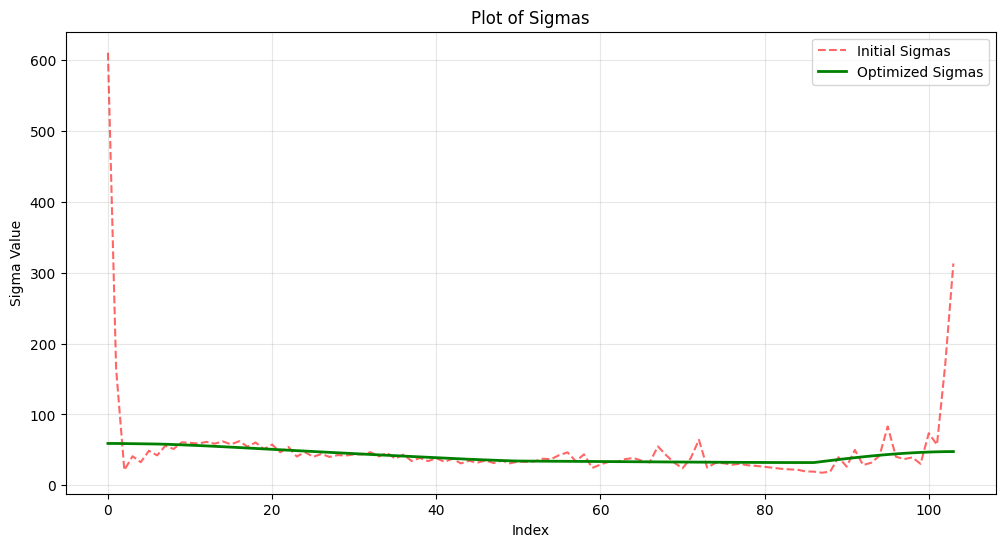

In [8]:
# Model constants
S0 = 1271.87
R1, R2 = 70, 34

# Load market data into NumPy
market_bid_ask = get_bid_ask('Quotes.csv')

# Initial parameters (Converted from your previous lists)
initial_nus1 = np.array([0, 985.8952130330157, 1103.9, 1105.6299717509714, 1108.9, 1110.9261114114317, 1113.9, 1116.0803462760916, 1118.9, 1121.217532062242, 1123.9, 1126.4524566940233, 1128.9, 1131.482542383951, 1133.9, 1136.5181574323626, 1138.9, 1141.5955696582002, 1143.9, 1146.6439410206626, 1148.9, 1151.6955052869373, 1153.9, 1156.7899943184998, 1158.9, 1161.6254606809712, 1163.9, 1166.5610218554195, 1168.9, 1171.459730260086, 1173.9, 1176.4403363141735, 1178.9, 1181.615546573849, 1183.9, 1186.6888172217348, 1188.9, 1191.7378244235415, 1193.9, 1196.5483693501587, 1198.8, 1201.5325443234078, 1203.8, 1206.5944516093734, 1208.8, 1211.4560716332721, 1213.8, 1216.4902257056644, 1218.8, 1221.5020603603978, 1223.8, 1226.3861829743955, 1228.8, 1231.2336479134826, 1233.8, 1236.1780621637572, 1238.8, 1241.7477258299014, 1243.8, 1247.0561689330698, 1248.8, 1251.2009300066638, 1253.8, 1256.2167752285077, 1258.8, 1261.4846983461696, 1263.8, 1265.7099860650808, 1268.8, 1270.5770900753105])
initial_sigs1 = np.array([610.4320996213446, 164.04874695079099, 21.410699478563217, 41.036799095433764, 32.59140099151007, 48.77559067919313, 42.2176372999541, 55.823566769595985, 51.211167181688566, 60.691607330511374, 59.950820637770775, 58.898463641159154, 61.253284806200256, 58.77606559998955, 61.9431978849179, 57.790240203069374, 62.2779153688338, 54.621537161593736, 60.38808834808558, 50.96497274766389, 57.49812984113923, 46.576659253726845, 54.080819207223875, 40.60311710082493, 46.79656147874567, 40.230053767550686, 44.17878499997829, 40.0738197788728, 42.59425882166232, 41.97429249407287, 43.554019179773334, 43.64066412990515, 46.68459597597928, 40.66643248490499, 45.74533322390213, 37.58570160756966, 43.36876861252296, 34.281419881606425, 38.63837902433531, 34.11699307804324, 38.33534468465065, 33.11788846662374, 37.54304297301797, 30.8995436545175, 34.629132576982585, 31.932382438352974, 34.99302768634262, 31.44000481459117, 34.80339761657143, 31.011124152999194, 33.67039062291056, 32.963580616942636, 33.88070107871873, 37.490458108901564, 36.9523875799828, 42.71457754035583, 46.473166992677335, 33.8545330176666, 43.67858033724246, 24.46553767335429, 29.27267842043444, 33.253868886417095, 32.860201483329625, 36.87919843993161, 38.56770262319378, 34.89031672560033, 32.336062185014455, 54.86203086146442, 42.54094598147429, 31.82466458162184])
initial_nus2 = np.array([1272.6042131350682, 1273.8, 1277.3405408056378, 1278.8, 1281.2353139855318, 1283.8, 1286.1696012675789, 1288.8, 1291.2560021979807, 1293.8, 1296.2794535546955, 1298.8, 1301.213819395613, 1303.7, 1306.2617186435, 1308.7, 1311.232700889095, 1313.7, 1316.810048833819, 1323.7, 1327.0068556961314, 1333.7, 1336.0240360741054, 1338.7, 1343.4698860472697, 1353.7, 1356.277830214803, 1358.7, 1361.5021167401464, 1363.7, 1377.3378359299822, 1388.7, 1503.7243622969859, 2000.0])
initial_sigs2 = np.array([24.02631471182734, 38.31350500726014, 64.22160217291687, 24.945880842361603, 31.475272346451945, 31.167940240782592, 29.04149431455202, 30.22926871363152, 28.245473181139502, 27.3473961133823, 26.078699124964757, 24.718907886876814, 23.35903470115683, 22.454368334929534, 22.002320937211316, 19.569326547161026, 19.315256975829875, 17.756271425921597, 19.392408982133873, 39.61543966355491, 26.387286176796366, 49.89596975113815, 28.527769674700764, 31.874820986884167, 41.72362039958813, 83.04797290752168, 40.34143759307382, 37.0089135084597, 39.353339426345215, 30.273572809409785, 73.52830072545393, 57.33057445441953, 169.4372302588361, 313.0441713343745])

init_theta = np.concatenate([initial_nus1, initial_sigs1, initial_nus2, initial_sigs2])

# Run Optimization
opt_theta = coordinateDescent(R1, R2, S0, init_theta, market_bid_ask, num_iterations= 20000)

# Visualize Results
init_sigs = np.concatenate([initial_sigs1, initial_sigs2])
opt_sigs = np.concatenate([opt_theta[R1:2*R1], opt_theta[2*R1+R2:]])

plt.figure(figsize=(12, 6))
plt.plot(init_sigs, 'r--', alpha=0.6, label='Initial Sigmas')
plt.plot(opt_sigs, 'g-', linewidth=2, label='Optimized Sigmas')
plt.title('Plot of Sigmas')
plt.xlabel('Index')
plt.ylabel('Sigma Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Even though the objective is different, it still minimizes J to a crazy degree. Here we print reduction in the original objective J.

In [10]:
# Calculate J for initial parameters
c_v1_init, c_v2_init = load_c_values(R1, R2, S0, init_theta)
j_init = calculate_J(R1, R2, S0, init_theta, c_v1_init, c_v2_init)

# Calculate J for optimized parameters
c_v1_opt, c_v2_opt = load_c_values(R1, R2, S0, opt_theta)
j_opt = calculate_J(R1, R2, S0, opt_theta, c_v1_opt, c_v2_opt)

# Calculate percent reduction
reduction = (j_init - j_opt) / j_init * 100

print(f"Initial J (Jump Metric): {j_init:.8f}")
print(f"Final J (Jump Metric):   {j_opt:.8f}")
print(f"Percent Reduction in J:  {reduction:.2f}%")

Initial J (Jump Metric): 0.00125289
Final J (Jump Metric):   0.00000060
Percent Reduction in J:  99.95%


# A plot of C(K), along with bid-ask ranges.

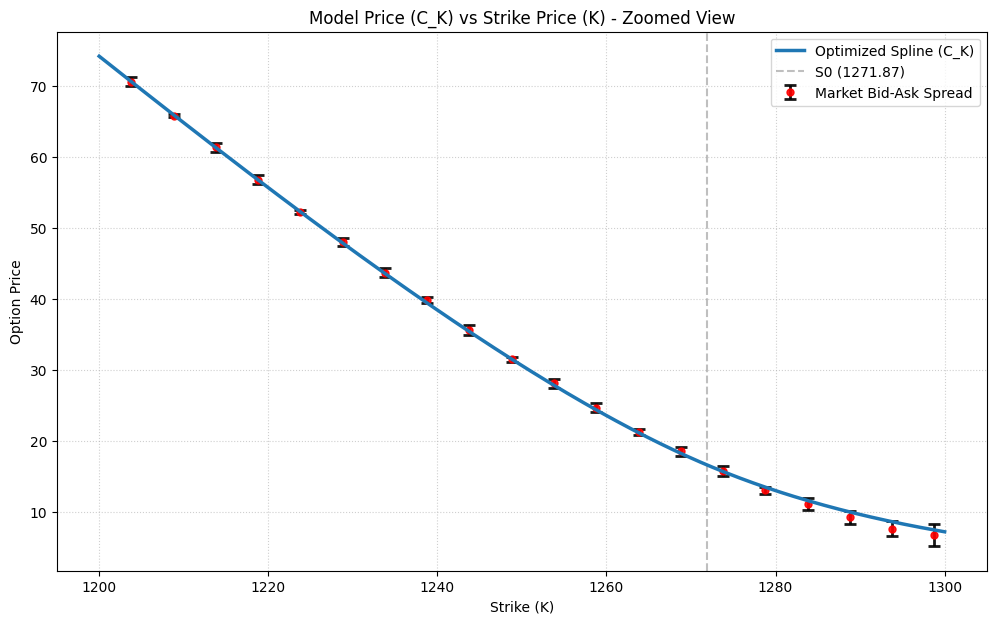

In [11]:
# 1. Define the range for K
nus1 = opt_theta[0:R1]
nus2 = opt_theta[2*R1 : 2*R1 + R2]

k_min = 1200
k_max = 1300

# Generate a smooth range of K values for the model line
K_plot = np.linspace(k_min, k_max, 500)

# 2. Pre-calculate c_v values
c_v1_opt, c_v2_opt = load_c_values(R1, R2, S0, opt_theta)

# 3. Calculate model prices
model_prices = np.array([C_K(k, R1, R2, S0, opt_theta, c_v1_opt, c_v2_opt) for k in K_plot])

# 4. Filter market data
mask = (market_bid_ask[:, 0] >= k_min) & (market_bid_ask[:, 0] <= k_max)
market_subset = market_bid_ask[mask]

strikes = market_subset[:, 0]
bids = market_subset[:, 1]
asks = market_subset[:, 2]
mid_prices = (bids + asks) / 2
yerr = [(mid_prices - bids), (asks - mid_prices)]

# 5. Plotting with enhanced error bars
plt.figure(figsize=(12, 7))

# Plot the spline model
plt.plot(K_plot, model_prices, color='#1f77b4', label='Optimized Spline (C_K)', linewidth=2.5, zorder=3)

# Add more apparent market bid-ask error bars
plt.errorbar(strikes, mid_prices, yerr=yerr, fmt='o', color='red',
             ecolor='black', elinewidth=2, capsize=4, capthick=2, markersize=5,
             label='Market Bid-Ask Spread', alpha=0.9, zorder=2)

plt.axvline(S0, color='gray', linestyle='--', alpha=0.5, label=f'S0 ({S0})')
plt.title('Model Price (C_K) vs Strike Price (K) - Zoomed View')
plt.xlabel('Strike (K)')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# A plot of C"(K). Major jumps are no more. It's shape is quite interesting, as if the optimal shape is 2 exponentials. Don't really know why this is.

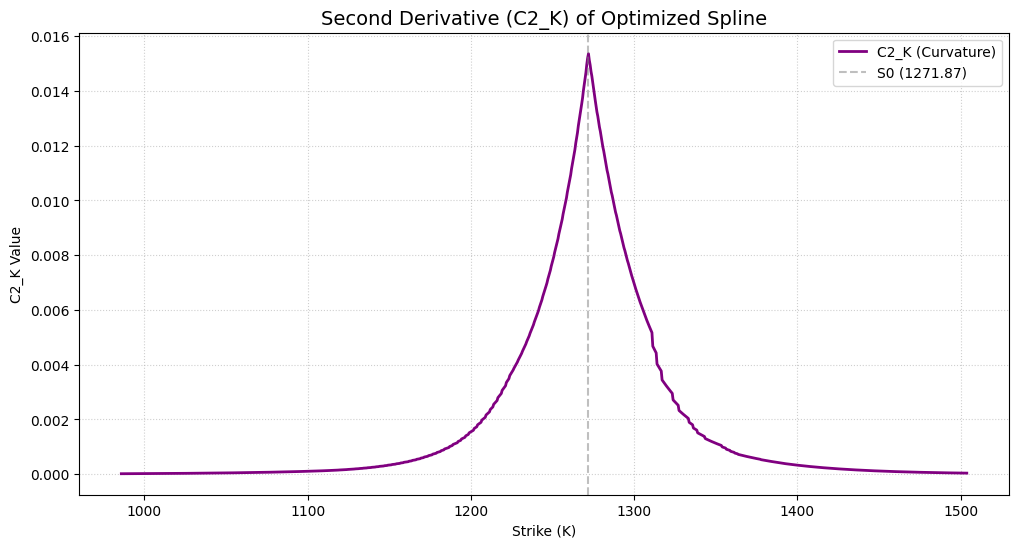

In [12]:
# 1. Pre-calculate c_v values for the optimized theta
c_v1_opt, c_v2_opt = load_c_values(R1, R2, S0, opt_theta)

# 2. Extract the range from nus[1] to nus2[-2]
nus1 = opt_theta[0:R1]
nus2 = opt_theta[2*R1 : 2*R1 + R2]
k_min_plot = nus1[1]
k_max_plot = nus2[-2]

# 3. Generate strike range and calculate C2_K
K_range = np.linspace(k_min_plot, k_max_plot, 1000)
c2_values = np.array([C2_K(k, R1, R2, S0, opt_theta, c_v1_opt, c_v2_opt) for k in K_range])

# 4. Plotting
plt.figure(figsize=(12, 6))
plt.plot(K_range, c2_values, color='purple', linewidth=2, label='C2_K (Curvature)')
plt.axvline(S0, color='gray', linestyle='--', alpha=0.5, label=f'S0 ({S0})')

plt.title('Second Derivative (C2_K) of Optimized Spline', fontsize=14)
plt.xlabel('Strike (K)')
plt.ylabel('C2_K Value')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Here, we run the algorithm 5 times and plot the results. Switch algo to RCD before viewing. They seem to converge to a similar theta, however some trials may end up getting stuck.

Starting 5 independent optimization runs (10k iterations each)...
Run 1/5...
Iteration 0/20000 | Loss: 266648.797024
Iteration 1000/20000 | Loss: 2269.046633
Iteration 2000/20000 | Loss: 783.869392
Iteration 3000/20000 | Loss: 515.718340
Iteration 4000/20000 | Loss: 369.286588
Iteration 5000/20000 | Loss: 281.100879
Iteration 6000/20000 | Loss: 226.269620
Iteration 7000/20000 | Loss: 179.621291
Iteration 8000/20000 | Loss: 147.377723
Iteration 9000/20000 | Loss: 120.309664
Iteration 10000/20000 | Loss: 99.874901
Iteration 11000/20000 | Loss: 85.894225
Iteration 12000/20000 | Loss: 73.420383
Iteration 13000/20000 | Loss: 63.654570
Iteration 14000/20000 | Loss: 56.677452
Iteration 15000/20000 | Loss: 50.184069
Iteration 16000/20000 | Loss: 45.079133
Iteration 17000/20000 | Loss: 40.453607
Iteration 18000/20000 | Loss: 36.659468
Iteration 19000/20000 | Loss: 33.699532
  > Final Loss: 30.850671
Run 2/5...
Iteration 0/20000 | Loss: 266648.797024
Iteration 1000/20000 | Loss: 2269.046633
Iter

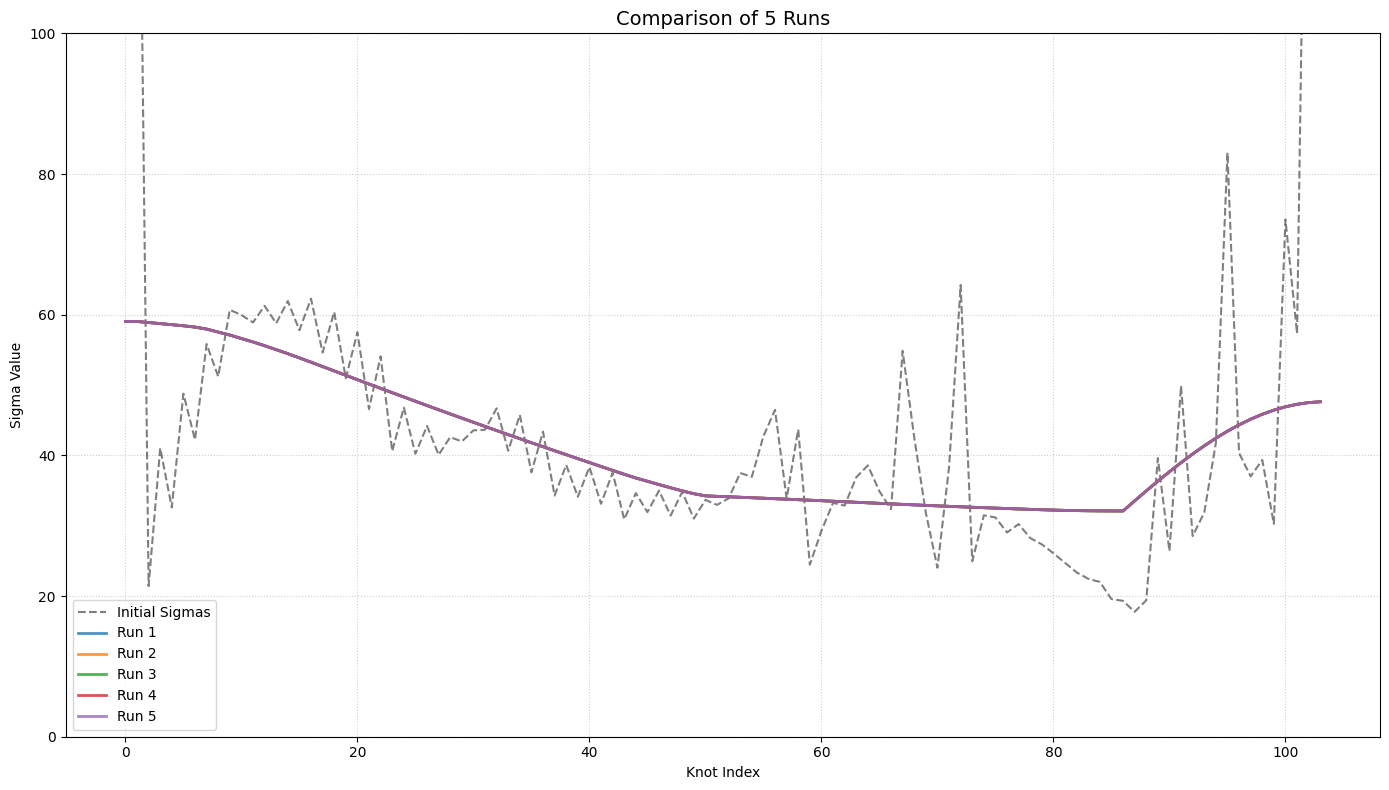

In [13]:
num_runs = 5
multi_run_results = []

print(f"Starting {num_runs} independent optimization runs (10k iterations each)...")
for r in range(num_runs):
    print(f"Run {r+1}/{num_runs}...")
    res_theta = coordinateDescent(R1, R2, S0, init_theta, market_bid_ask, num_iterations=20000)

    res_sigs = np.concatenate([res_theta[R1:2*R1], res_theta[2*R1+R2:]])
    final_loss = newObjective(res_sigs)
    multi_run_results.append(res_sigs)
    print(f"  > Final Loss: {final_loss:.6f}")

# Plotting
plt.figure(figsize=(14, 8))
plt.plot(init_sigs, 'k--', alpha=0.5, label='Initial Sigmas', linewidth=1.5)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, sigs in enumerate(multi_run_results):
    plt.plot(sigs, color=colors[i], alpha=0.8, linewidth=2, label=f'Run {i+1}')
plt.title('Comparison of 5 Runs', fontsize=14)
plt.xlabel('Knot Index')
plt.ylabel('Sigma Value')
plt.ylim(0, 100)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# If you run coordinate descent for enough iterations, it eventually stalls and doesn't make improvement. As the sigmas gets closer together, subsequent iterations move each coordinate less. Of course, constraints may also bottleneck improvement.

# I am curious though if optimization with gradient-based could be applied after this algo to make further progress.